# Sultanov Kanan 606.23E – K-Means Clustering Lab 4

## Objective
Understand and implement K-Means clustering on real and synthetic datasets.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

%config InlineBackend.figure_format = 'retina'

In [2]:
apartment_for_rent_classified = fetch_ucirepo(id=555)

X = apartment_for_rent_classified.data.features

/Users/konansul/Library/Python/3.9/lib/python/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0,5,6,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
X

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,2195,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,1250,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,1395,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09
3,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1,2,USD,No,Thumbnail,"Cats,Dogs",...,1600,Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1.577360e+09
4,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1,1,USD,No,Thumbnail,"Cats,Dogs",...,975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1.577360e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99821,housing/rent/apartment,Houston - superb Apartment nearby fine dining,"Redefining urban living, in southeast Houston,...","Gym,Parking,Patio/Deck,Playground,Storage,Wood...",1.0,1.0,USD,No,Yes,NaN,...,780,Monthly,605,NaN,Houston,TX,29.6151,-95.1998,RentDigs.com,1.544186e+09
99822,housing/rent/apartment,The Best of the Best in the City of Jacksonvil...,Courtney Manor Apartments offer the best of ev...,"AC,Cable or Satellite,Clubhouse,Dishwasher,Gym...",2.0,2.0,USD,No,Yes,"Cats,Dogs",...,813,Monthly,921,NaN,Jacksonville,FL,30.2254,-81.7579,RentDigs.com,1.544186e+09
99823,housing/rent/apartment,A great & large One BR apartment. Pet OK!,"Fully remodeled, new floor, kitchen cabinet, s...","Garbage Disposal,Refrigerator",1.0,1.0,USD,No,Yes,"Cats,Dogs",...,1325,Monthly,650,NaN,San Diego,CA,32.7379,-117.0914,RentDigs.com,1.544186e+09
99824,housing/rent/apartment,"The Crest offers studio, 1, 2 & Three BR homes...","Amenities include a fitness facilities, swimmi...","Gym,Pool",1.0,1.0,USD,No,Yes,"Cats,Dogs",...,931,Monthly,701,NaN,Huntersville,NC,35.4158,-80.8451,RentDigs.com,1.544186e+09


In [4]:
X.columns

Index(['category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [5]:
X.dtypes

category          object
title             object
body              object
amenities         object
bathrooms         object
bedrooms          object
currency          object
fee               object
has_photo         object
pets_allowed      object
price            float64
price_display     object
price_type        object
square_feet       object
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time             float64
dtype: object

In [6]:
X.isna().sum()

category             0
title                0
body                 0
amenities        16077
bathrooms           66
bedrooms           127
currency             4
fee                  3
has_photo            3
pets_allowed     60634
price                5
price_display        6
price_type           3
square_feet          3
address          91880
cityname           305
state              305
latitude            29
longitude           31
source               6
time                 6
dtype: int64

In [7]:
df_clean = X.copy()

In [8]:
df_clean['bathrooms'] = pd.to_numeric(df_clean['bathrooms'], errors='coerce')
df_clean['bedrooms'] = pd.to_numeric(df_clean['bedrooms'], errors='coerce')
df_clean['square_feet'] = pd.to_numeric(df_clean['square_feet'], errors='coerce')

In [9]:
binary_map = {'Yes': 1, 'No': 0, 'Thumbnail': 1}
df_clean['fee_encoded'] = df_clean['fee'].map(binary_map).fillna(0)
df_clean['has_photo_encoded'] = df_clean['has_photo'].map(binary_map).fillna(0)

In [10]:
df_clean['pets_allowed_encoded'] = df_clean['pets_allowed'].apply(
        lambda x: 0 if pd.isna(x) or x == 'None' else 1
    )

In [11]:
cat_cols = ['category', 'cityname', 'state', 'source']

for col in cat_cols:
    df_clean[col] = df_clean[col].astype('category').cat.codes

In [12]:
numeric_features = ['price', 'bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude', 'time']

for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [13]:
cols_to_drop = [
        'title', 'body', 'amenities', 'address',
        'price_display', 'currency', 'price_type',
        'fee', 'has_photo', 'pets_allowed'
    ]

df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

In [14]:
df_clean.isna().sum()

category                0
bathrooms               0
bedrooms                0
price                   0
square_feet             0
cityname                0
state                   0
latitude                0
longitude               0
source                  0
time                    0
fee_encoded             0
has_photo_encoded       0
pets_allowed_encoded    0
dtype: int64

<Axes: >

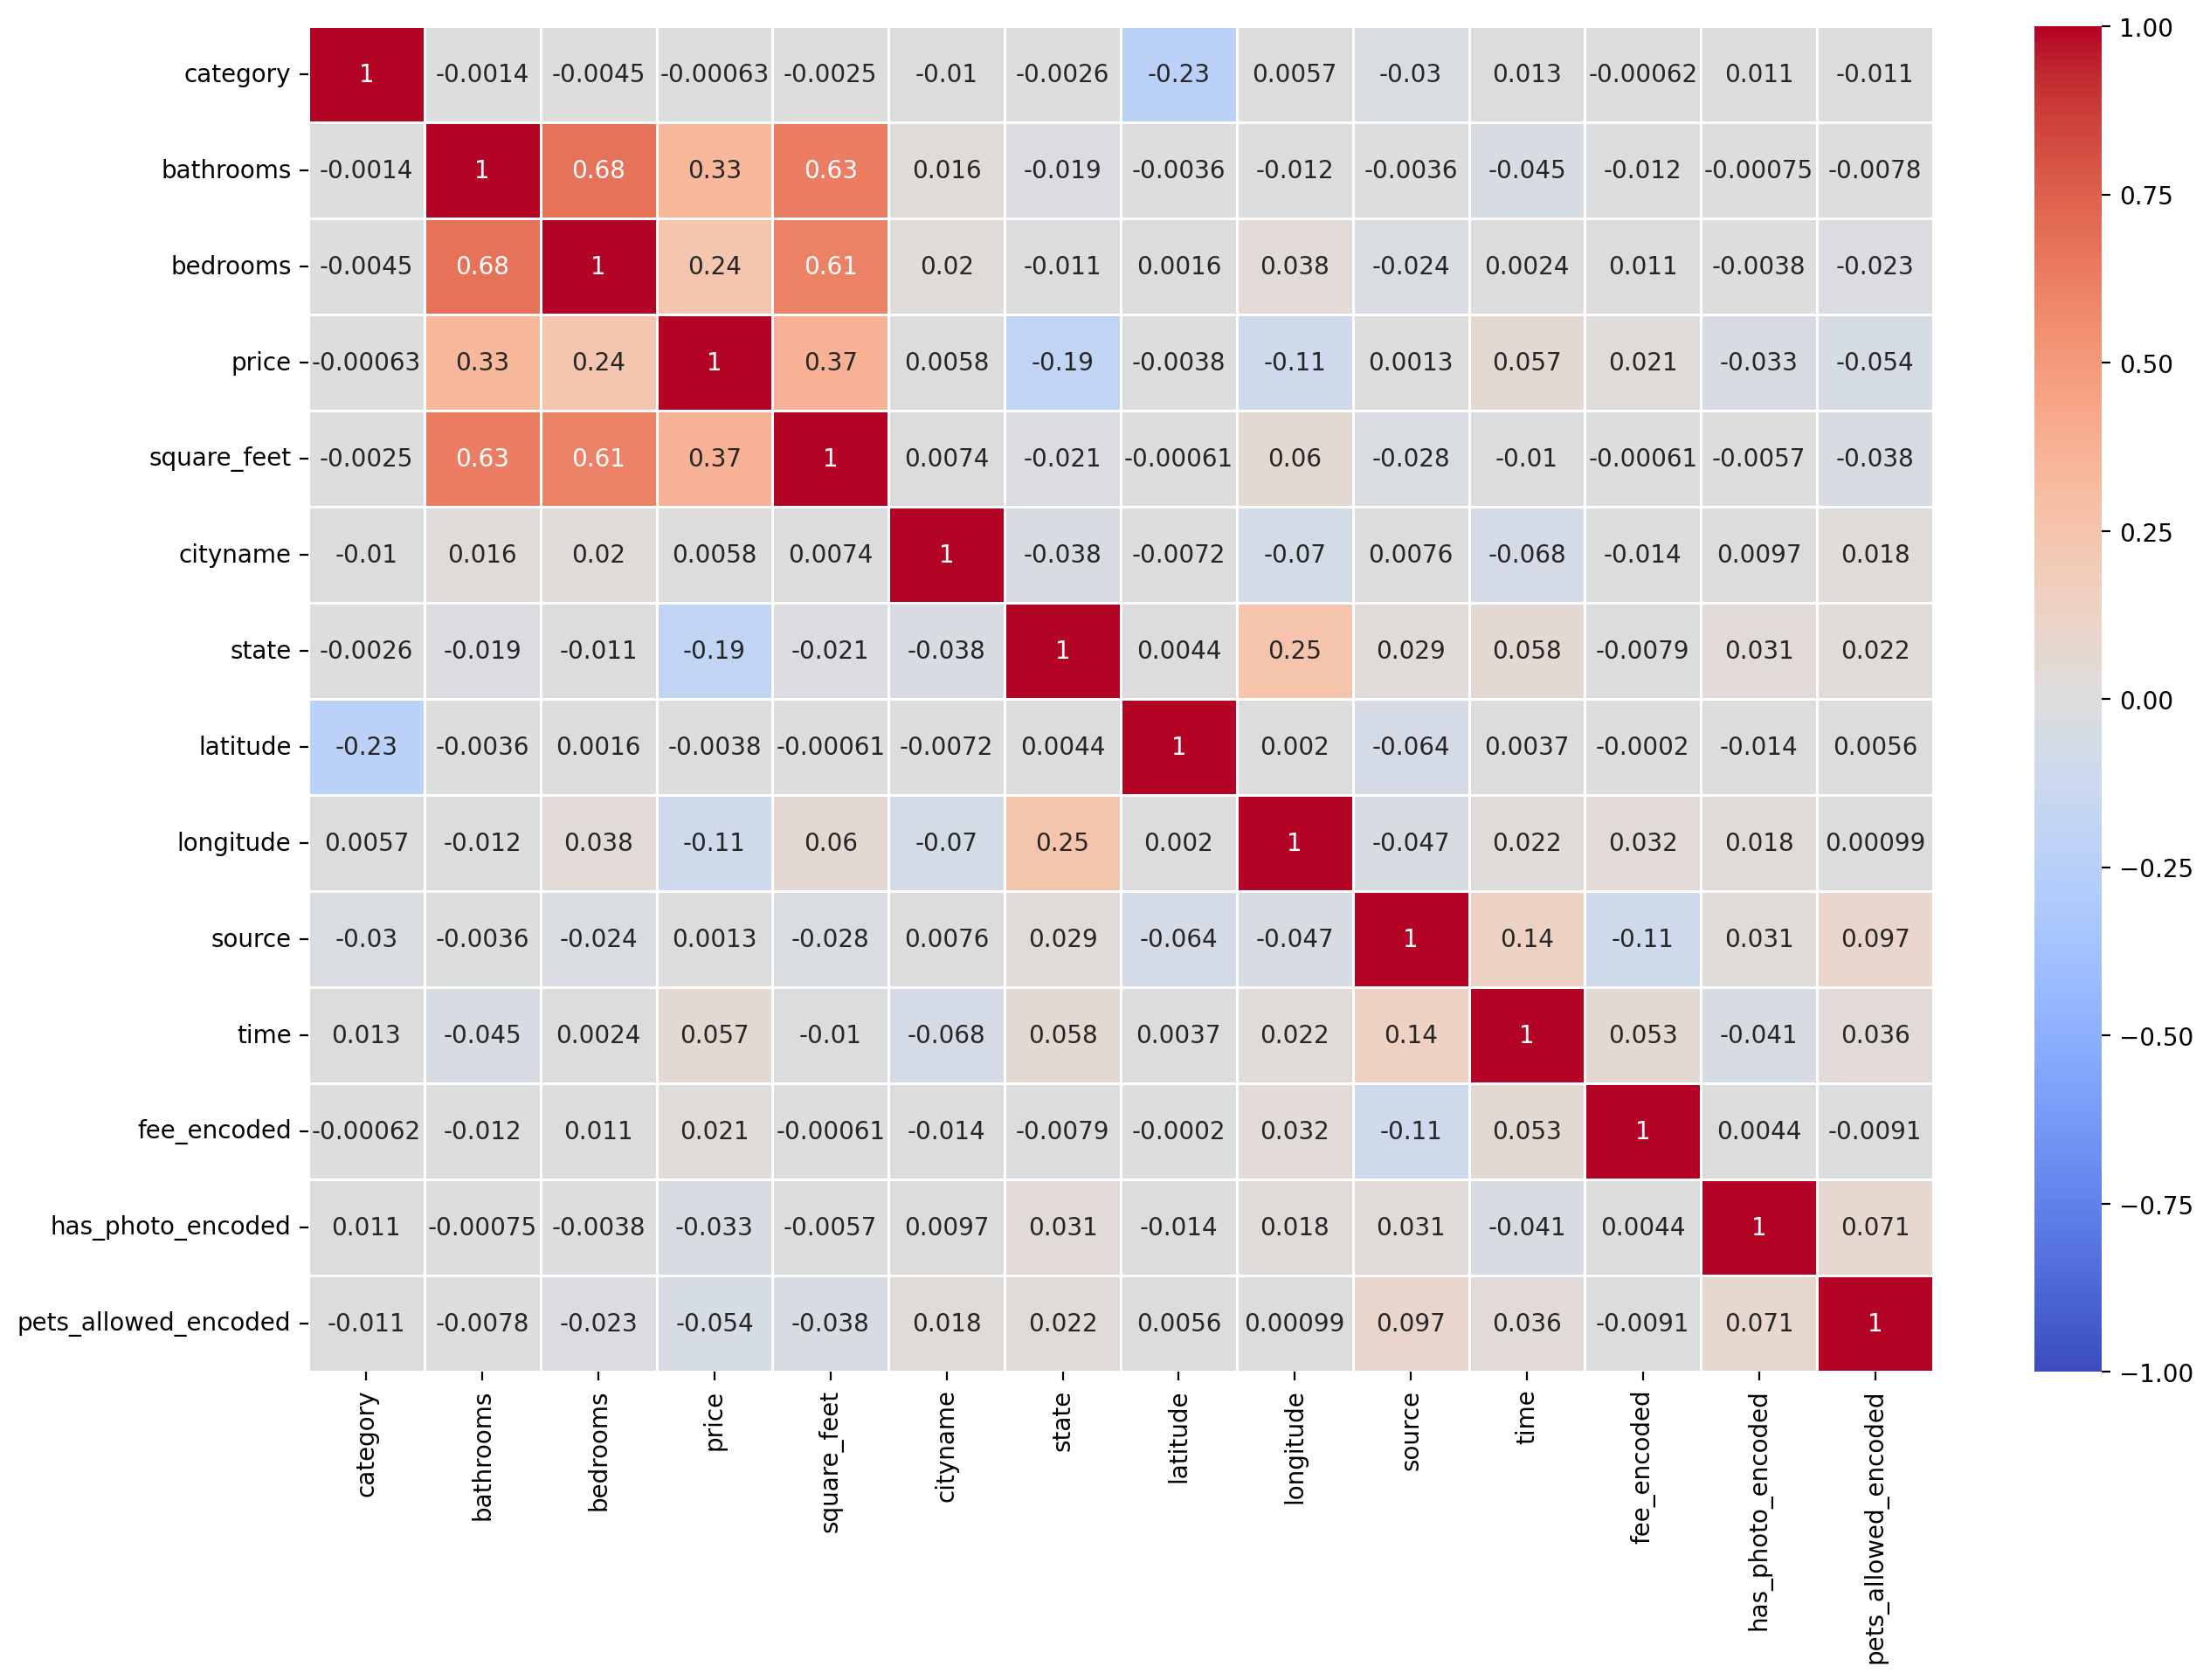

In [15]:
plt.figure(figsize = (15,10))
sns.heatmap(df_clean.corr(), annot = True, cmap = 'coolwarm', linewidths = 0.5, vmin = -1, vmax = 1)

# Task 2: Apply K-Means

In [16]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

labels = kmeans.fit_predict(df_clean)

In [17]:
labels

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

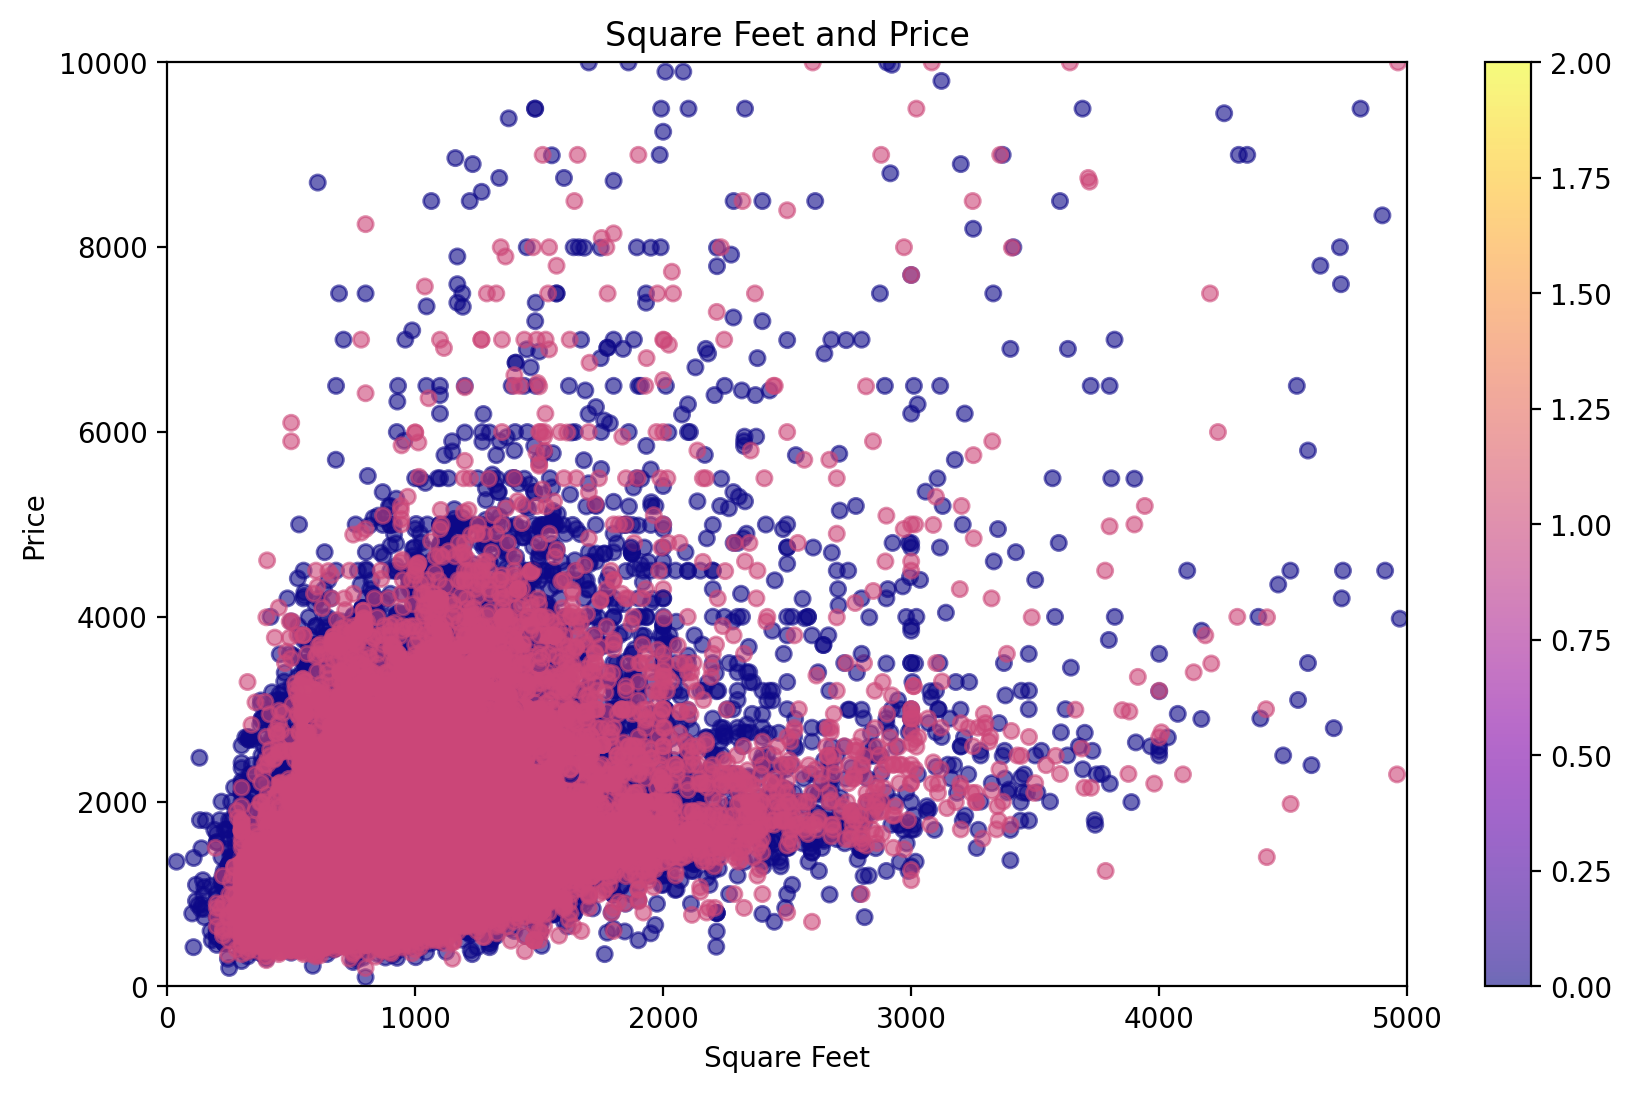

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(df_clean['square_feet'], df_clean['price'], c=labels, cmap='plasma', alpha=0.6, s=30)

plt.title("Square Feet and Price")
plt.xlabel("Square Feet")
plt.ylabel("Price")

plt.xlim(0, 5000) 
plt.ylim(0, 10000) 

plt.colorbar()

plt.show()

# Task 3: Elbow Method

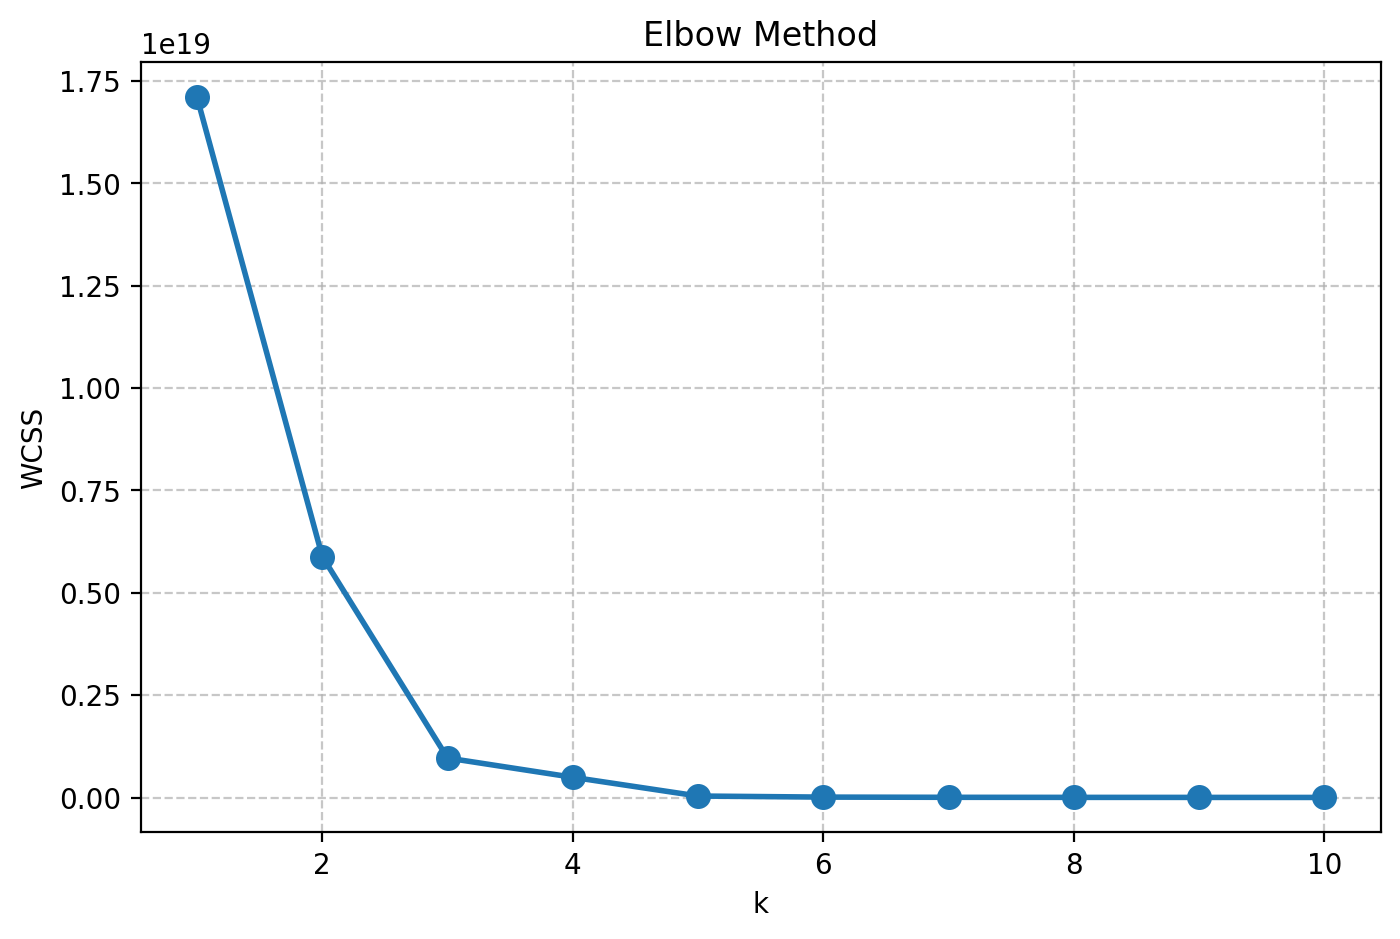

In [19]:
wcss = [ ]

k_min = 1
k_max = 11

for k in range(k_min, k_max):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_clean)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(k_min, k_max), wcss, marker='o', linewidth=2, markersize=8)

plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Task 4: Feature Scaling

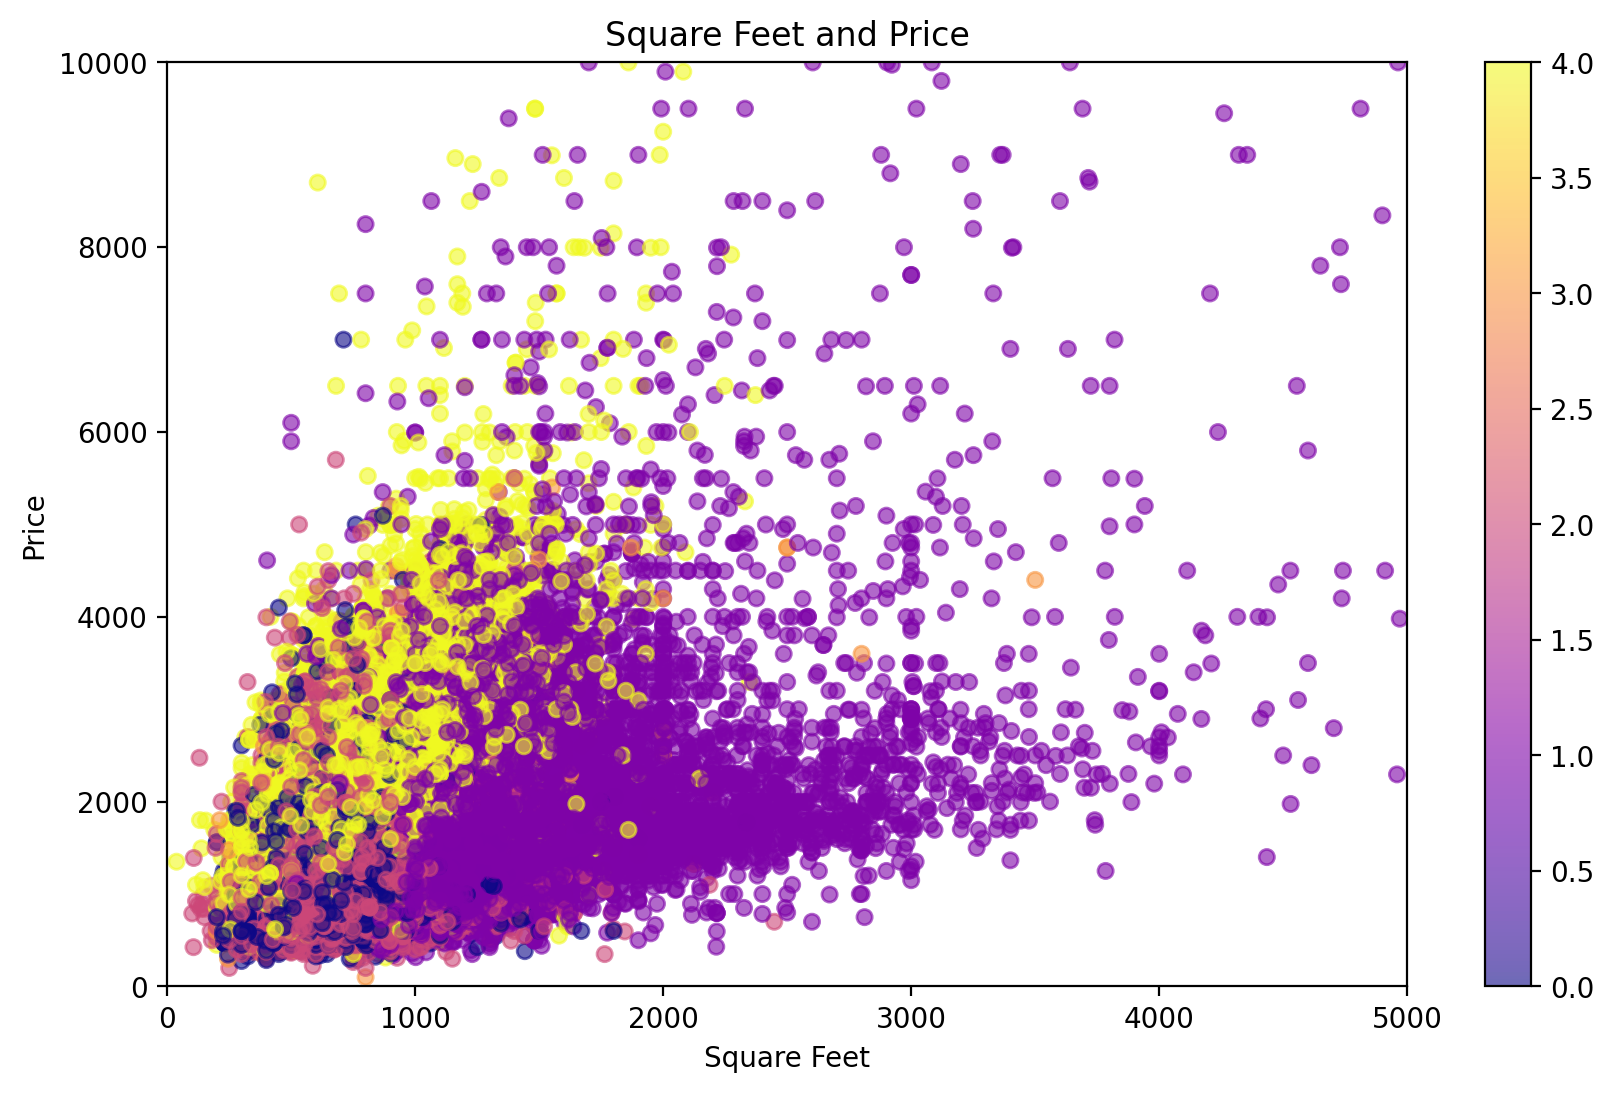

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean) 

k = 5

kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)


plt.figure(figsize=(10, 6))

plt.scatter(df_clean['square_feet'], df_clean['price'], c=labels, cmap='plasma', alpha=0.6, s=30)

plt.title("Square Feet and Price")
plt.xlabel("Square Feet")
plt.ylabel("Price")

plt.xlim(0, 5000) 
plt.ylim(0, 10000) 

plt.colorbar()

plt.show()

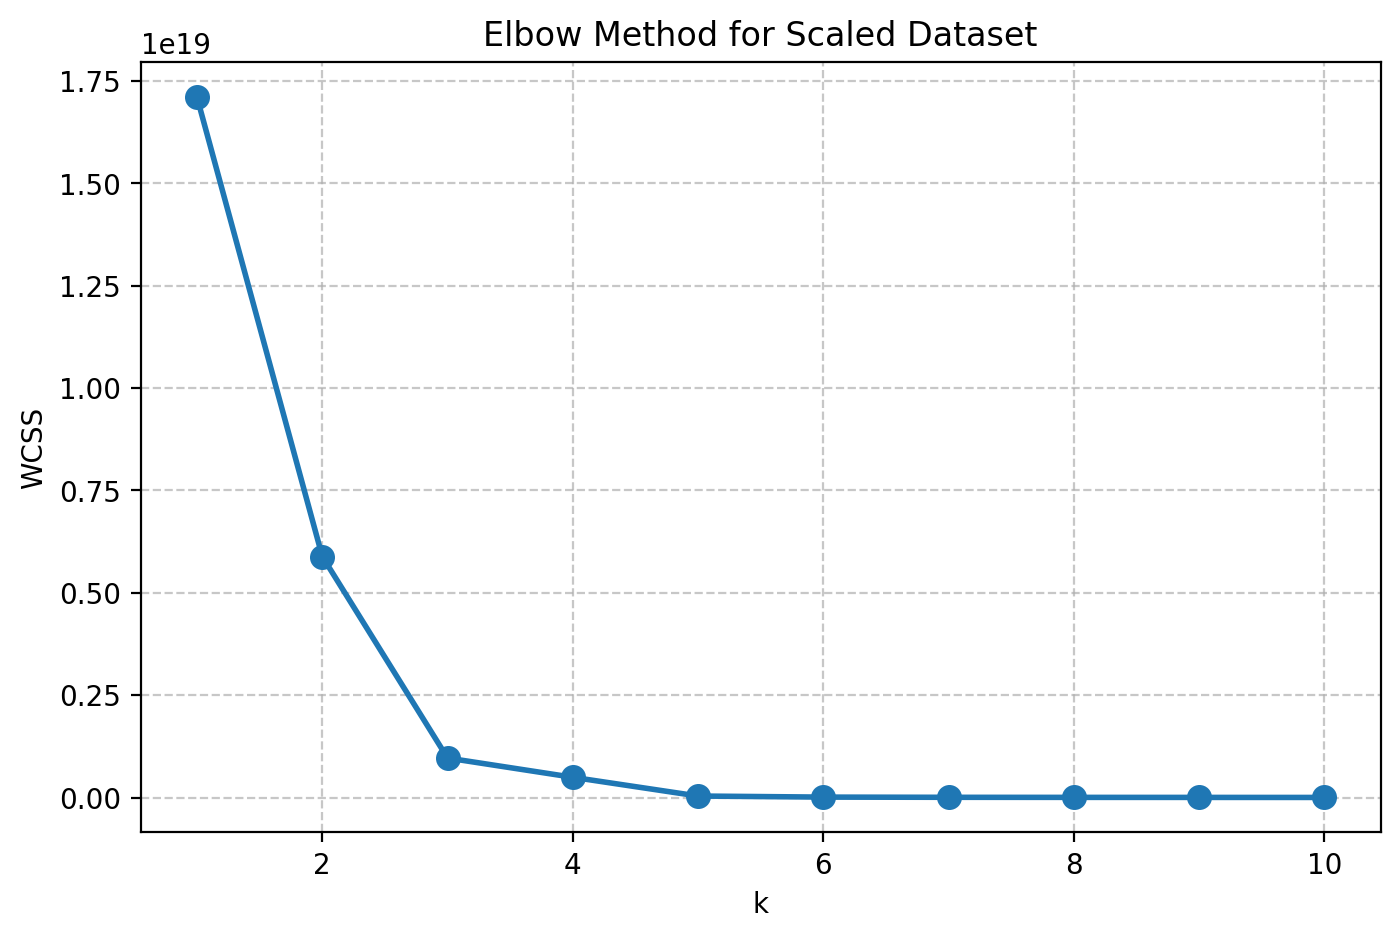

In [21]:
wcss_scaled = []

k_min = 1
k_max = 11

for k in range(k_min, k_max):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss_scaled.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(k_min, k_max), wcss, marker='o', linewidth=2, markersize=8)

plt.title("Elbow Method for Scaled Dataset")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

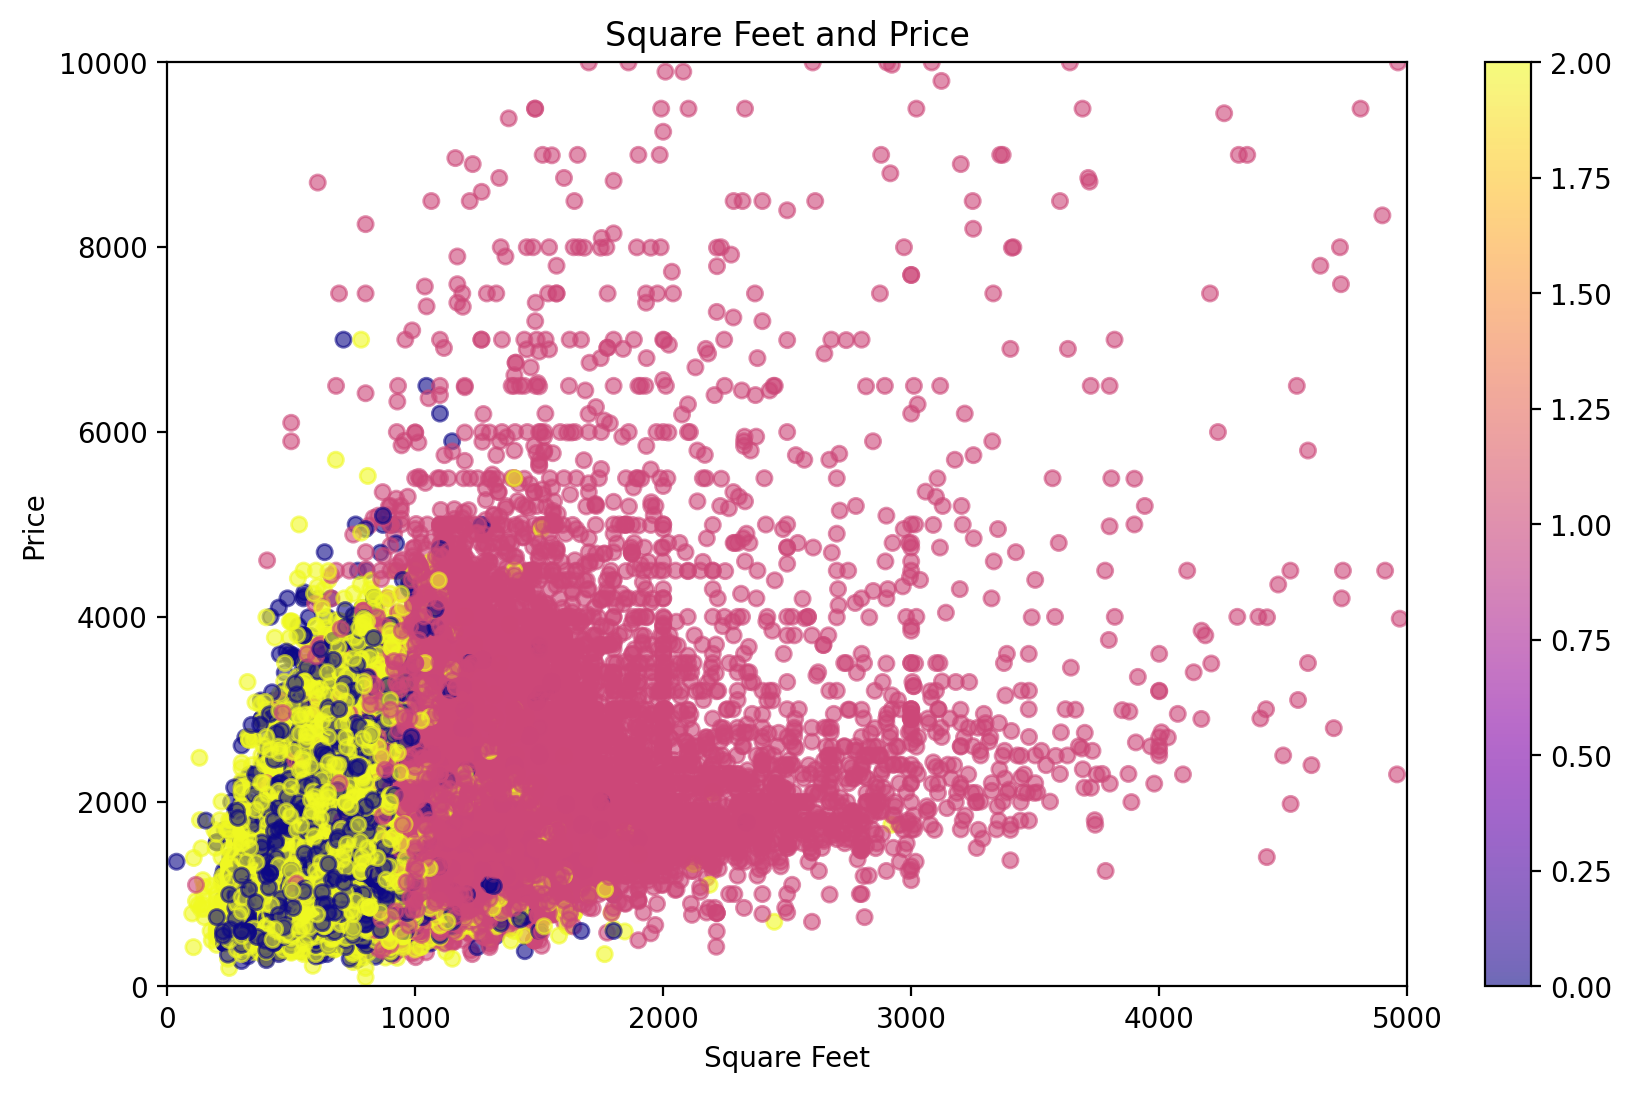

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean) 

k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)


plt.figure(figsize=(10, 6))

plt.scatter(df_clean['square_feet'], df_clean['price'], c=labels, cmap='plasma', alpha=0.6, s=30)

plt.title("Square Feet and Price")
plt.xlabel("Square Feet")
plt.ylabel("Price")

plt.xlim(0, 5000) 
plt.ylim(0, 10000) 

plt.colorbar()

plt.show()

## Questions
1. What happens when K changes?
When you change K, you force the algorithm to divide your data into exactly that many distinct groups. A smaller K creates broader, more generalized clusters, while a larger K creates smaller, highly specific groups. If K is too large, it might overfit and start artificially separating data points that naturally belong together.

2. Why is scaling important?
K-Means relies on measuring the geometric distance (Euclidean distance) between data points to group them. If one feature has much larger numbers than another (like a price of $5,000 versus 2 bedrooms), the algorithm will treat the larger numbers as far more important and ignore the smaller ones. Scaling normalizes all features to the same range so they contribute equally to the final decision.

3. How does K-Means find clusters?
It starts by placing K random "centroids" (cluster centers) on the graph and assigning every data point to the nearest one. Then, it calculates the actual center of all the points in each group and moves the centroid to that new location. It repeats this "assign-and-move" process until the centroids stop moving, meaning the clusters are mathematically stable.
